In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/raw/Resume.csv')
print(df.shape)
df.head()

(2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


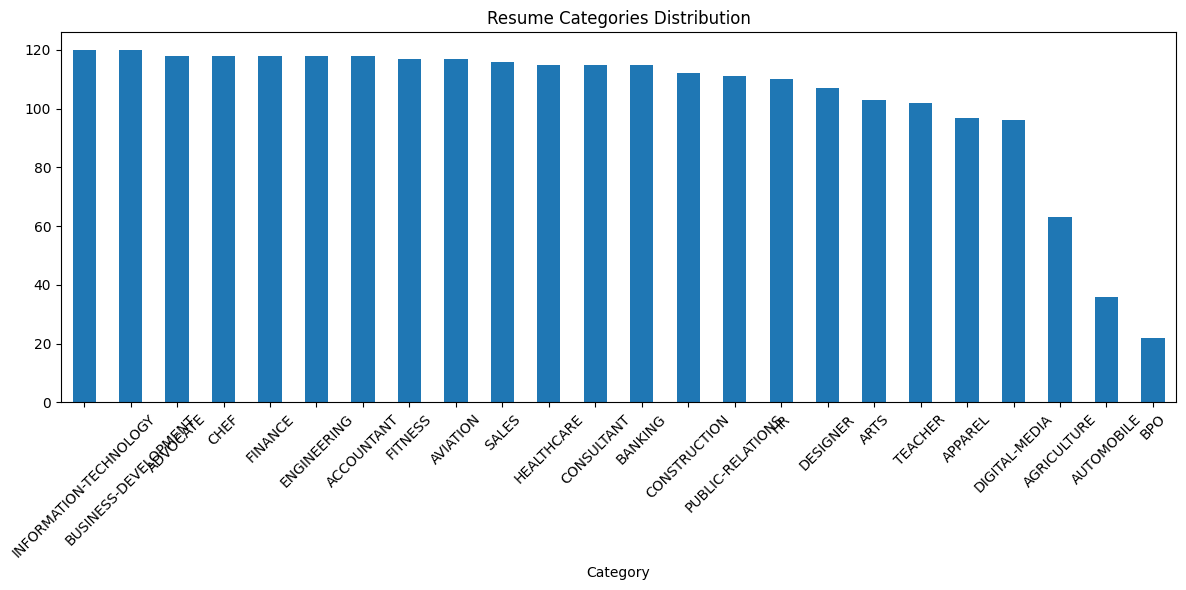

In [3]:
plt.figure(figsize=(12,6))
df['Category'].value_counts().plot(kind='bar')
plt.title('Resume Categories Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
import sys
sys.path.append('..')
from src.train import load_data, train_models
df = load_data()
results = train_models(df)

Dataset shape: (2484, 4)
Categories: 24
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Preprocessing text...

Fitting TF-IDF...

Training Logistic Regression...
Logistic Regression Accuracy: 0.6439
                        precision    recall  f1-score   support

            ACCOUNTANT      

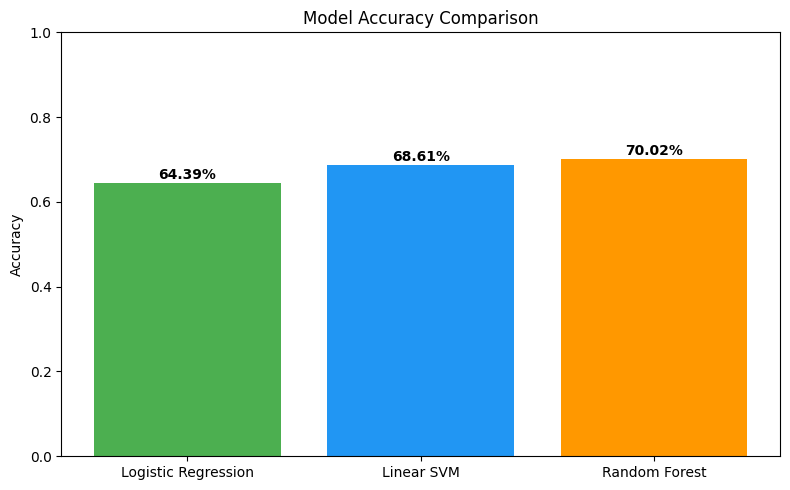

In [5]:
# Model accuracy comparison chart
plt.figure(figsize=(8,5))
colors = ['#4CAF50', '#2196F3', '#FF9800']
plt.bar(results.keys(), results.values(), color=colors)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Loaded: Random Forest


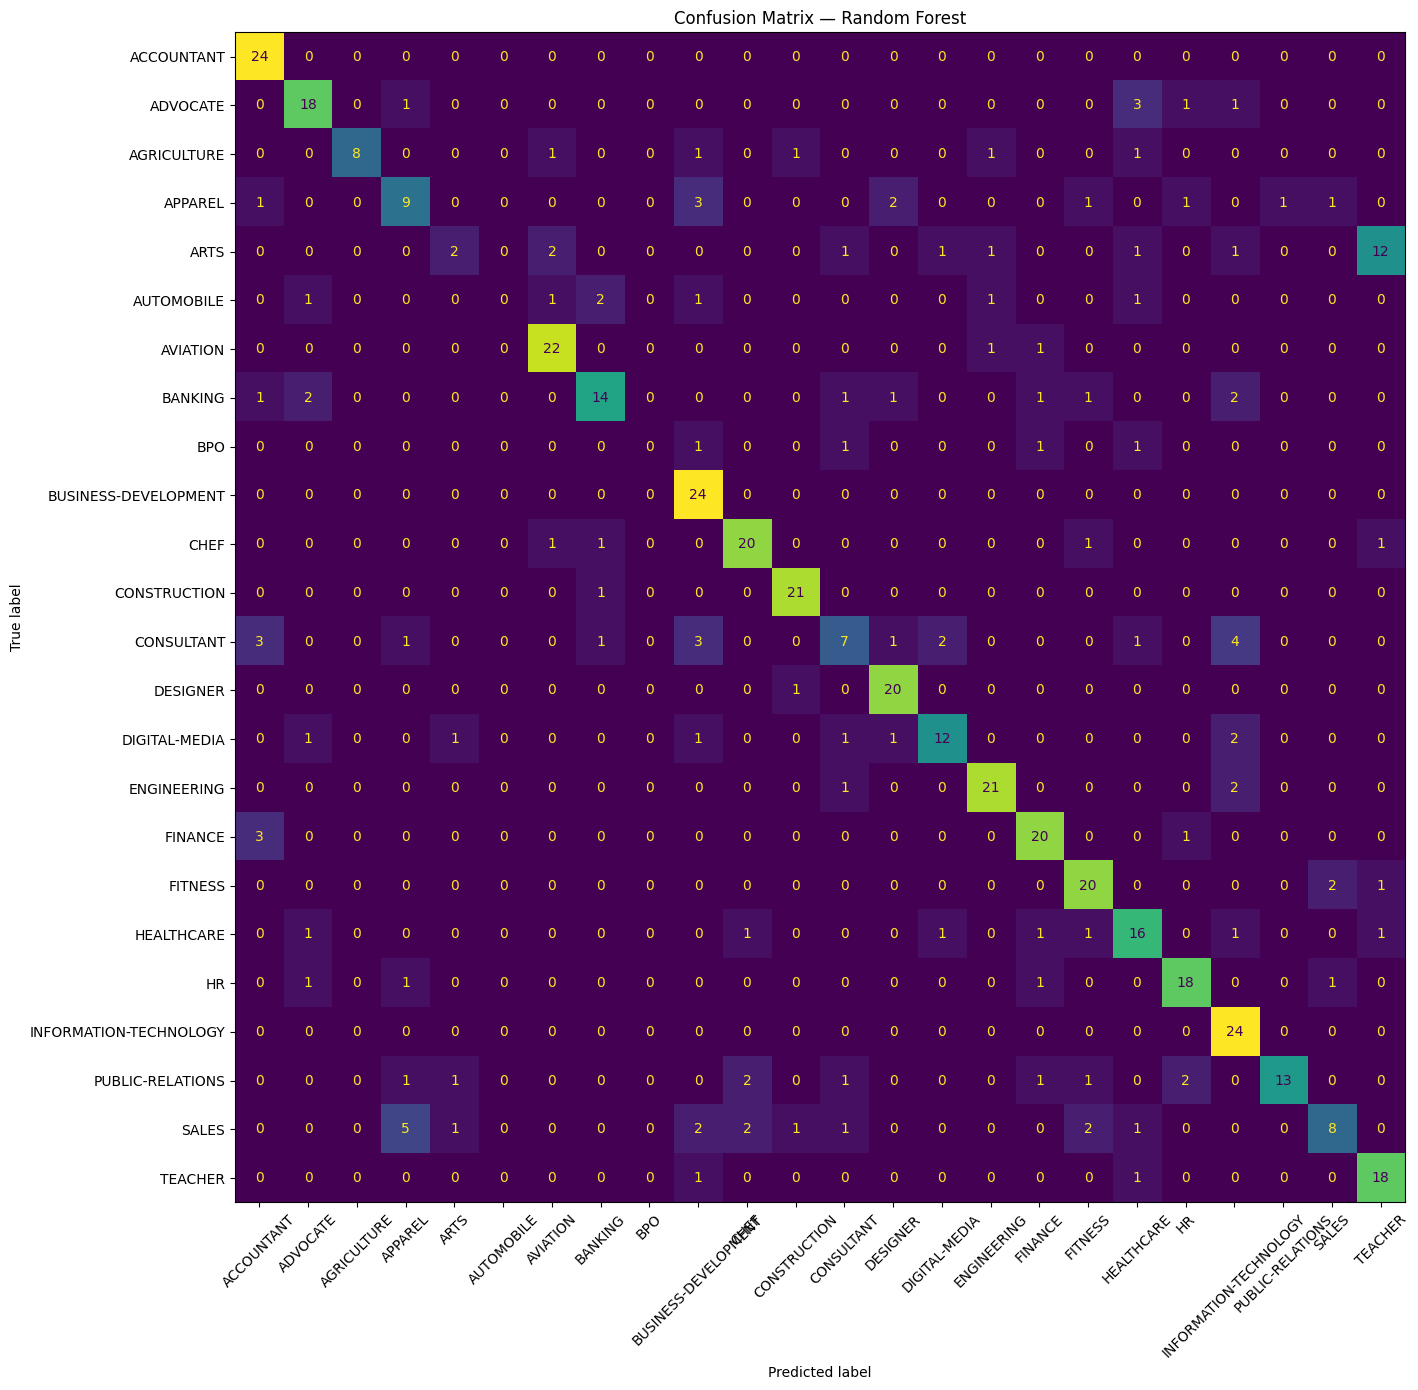

In [6]:
import joblib
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Load saved model
tfidf = joblib.load('../models/saved/tfidf.pkl')
model = joblib.load('../models/saved/classifier.pkl')
best_name = joblib.load('../models/saved/best_model_name.pkl')
print(f"Loaded: {best_name}")

# Prepare test data
df['clean'] = df['Resume_str'].apply(lambda x: x.lower())
X = tfidf.transform(df['clean'])
y = df['Category']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_pred = model.predict(X_test)

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()